In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ipywidgets import interact, IntSlider, Dropdown
from pathlib import Path

# Configuration graphique
%matplotlib inline
sns.set_theme(style="white")
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi'] = 100

In [2]:
GAP_MIN = -600
GAP_MAX = 400
GAP_OFFSET = -GAP_MIN  # 600
GRID_SIZE = GAP_MAX - GAP_MIN + 1  # 1001
N_MATCHES_FINALES = 32

# Gestion dynamique des chemins (Suppose que le notebook est dans un dossier /notebooks)
notebook_dir = Path.cwd()
project_root = notebook_dir.parent 
data_path = project_root / "data" / "expected_V_phases_finales.npy"

print(f"Chemin cible des données : {data_path}")
print(f"Configuration : 4D Grille de {N_MATCHES_FINALES}x{GRID_SIZE}x{GRID_SIZE}x2")

Chemin cible des données : d:\Documents\Code\MonPetitPronoStrategy\data\expected_V_phases_finales.npy
Configuration : 4D Grille de 32x1001x1001x2


In [3]:
try:
    # Chargement du cube 4D complet
    V_all_matches = np.load(data_path)
    print("✅ Fichier 'expected_V_phases_finales.npy' chargé avec succès !")
    print(f"Forme de la matrice 4D : {V_all_matches.shape}")
    
    # Extraction de la J72 (Indice 0)
    expected_V72 = V_all_matches[0]
    
    # Statistiques sur la J72
    mask_upper = np.triu(np.ones_like(expected_V72[:, :, 0], dtype=bool))
    
    # Séparation des univers Avec (1) et Sans (0) booster
    valid_values_b0 = expected_V72[:, :, 0][mask_upper]
    valid_values_b1 = expected_V72[:, :, 1][mask_upper]
    
    print("\n--- Statistiques de la J72 (Point d'entrée des phases finales) ---")
    print(f"Win Rate Max (Sans Booster) : {np.max(valid_values_b0):.4f}")
    print(f"Win Rate Max (Avec Booster) : {np.max(valid_values_b1):.4f}")
    print(f"Win Rate Min (Avec Booster) : {np.min(valid_values_b1):.4f}")
    
    wr_egalite_b0 = expected_V72[GAP_OFFSET, GAP_OFFSET, 0]
    wr_egalite_b1 = expected_V72[GAP_OFFSET, GAP_OFFSET, 1]
    
    print(f"\nWin Rate à égalité parfaite (0, 0) à la J72 (Sans Booster) : {wr_egalite_b0:.4f}")
    print(f"Win Rate à égalité parfaite (0, 0) à la J72 (Avec Booster) : {wr_egalite_b1:.4f}")

except FileNotFoundError:
    print(f"❌ Erreur : Fichier introuvable à {data_path}")

✅ Fichier 'expected_V_phases_finales.npy' chargé avec succès !
Forme de la matrice 4D : (32, 1001, 1001, 2)

--- Statistiques de la J72 (Point d'entrée des phases finales) ---
Win Rate Max (Sans Booster) : 0.9558
Win Rate Max (Avec Booster) : 0.9701
Win Rate Min (Avec Booster) : 0.1136

Win Rate à égalité parfaite (0, 0) à la J72 (Sans Booster) : 0.5395
Win Rate à égalité parfaite (0, 0) à la J72 (Avec Booster) : 0.6304


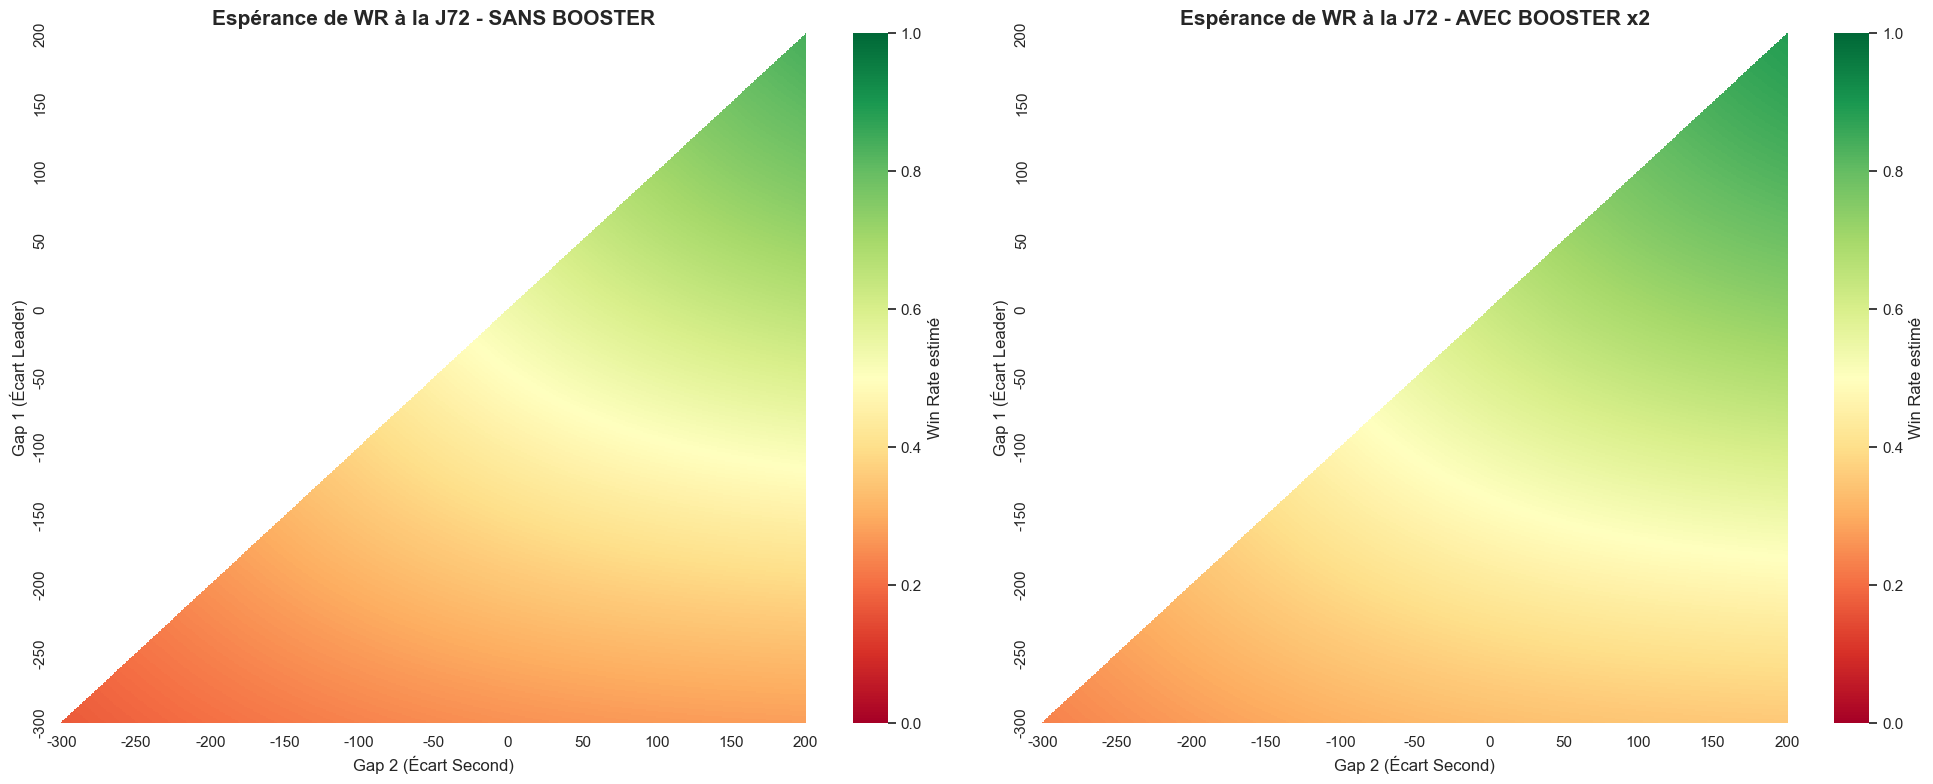

In [4]:
# Bornes de visualisation
V_MIN_PLOT = -300
V_MAX_PLOT = 200

idx_min_plot = V_MIN_PLOT + GAP_OFFSET
idx_max_plot = V_MAX_PLOT + GAP_OFFSET

# Extraction des sous-matrices J72 (Indice 0) pour b=0 et b=1
sub_matrix_j72_b0 = V_all_matches[0, idx_min_plot:idx_max_plot+1, idx_min_plot:idx_max_plot+1, 0]
sub_matrix_j72_b1 = V_all_matches[0, idx_min_plot:idx_max_plot+1, idx_min_plot:idx_max_plot+1, 1]

mask = np.tril(np.ones_like(sub_matrix_j72_b0, dtype=bool), k=-1)

ticks_gaps = np.arange(V_MIN_PLOT, V_MAX_PLOT + 1)
visible_ticks = [str(x) if x % 50 == 0 else "" for x in ticks_gaps]

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# 1. Heatmap SANS Booster
sns.heatmap(
    sub_matrix_j72_b0, mask=mask, cmap="RdYlGn", vmin=0.0, vmax=1.0,
    xticklabels=visible_ticks, yticklabels=visible_ticks,
    cbar_kws={'label': 'Win Rate estimé'}, ax=axes[0]
)
axes[0].set_title("Espérance de WR à la J72 - SANS BOOSTER", fontsize=15, fontweight='bold')
axes[0].set_xlabel("Gap 2 (Écart Second)", fontsize=12)
axes[0].set_ylabel("Gap 1 (Écart Leader)", fontsize=12)
axes[0].invert_yaxis()

# 2. Heatmap AVEC Booster
sns.heatmap(
    sub_matrix_j72_b1, mask=mask, cmap="RdYlGn", vmin=0.0, vmax=1.0,
    xticklabels=visible_ticks, yticklabels=visible_ticks,
    cbar_kws={'label': 'Win Rate estimé'}, ax=axes[1]
)
axes[1].set_title("Espérance de WR à la J72 - AVEC BOOSTER x2", fontsize=15, fontweight='bold')
axes[1].set_xlabel("Gap 2 (Écart Second)", fontsize=12)
axes[1].set_ylabel("Gap 1 (Écart Leader)", fontsize=12)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [5]:
def plot_temporal_heatmap(match_idx, has_booster):
    """Trace la heatmap pour un match spécifique des phases finales."""
    match_reel = match_idx + 72
    
    # On utilise la 4ème dimension `has_booster`
    sub_matrix = V_all_matches[match_idx, idx_min_plot:idx_max_plot+1, idx_min_plot:idx_max_plot+1, has_booster]
    mask = np.tril(np.ones_like(sub_matrix, dtype=bool), k=-1)

    plt.figure(figsize=(10, 7))
    sns.heatmap(
        sub_matrix, mask=mask, cmap="RdYlGn", vmin=0.0, vmax=1.0,
        xticklabels=visible_ticks, yticklabels=visible_ticks, cbar=False
    )
    
    match_restants = 32 - match_idx
    etat_boost = "AVEC Booster" if has_booster == 1 else "SANS Booster"
    plt.title(f"J{match_reel} [{etat_boost}] (Il reste {match_restants} matchs)", fontsize=14, fontweight='bold')
    plt.xlabel("Gap 2")
    plt.ylabel("Gap 1")
    plt.gca().invert_yaxis()
    plt.show()

# Slider interactif de 0 (J72) à 31 (J103)
interact(
    plot_temporal_heatmap,
    match_idx=IntSlider(min=0, max=N_MATCHES_FINALES-1, step=1, value=0, description="Temps (Indice)"),
    has_booster=Dropdown(options=[('Avec Booster (1)', 1), ('Sans Booster (0)', 0)], value=1, description='Booster')
);

interactive(children=(IntSlider(value=0, description='Temps (Indice)', max=31), Dropdown(description='Booster'…

In [6]:
def inspect_state(match_idx, gap_1, gap_2):
    if gap_1 > gap_2:
        print("⚠️ Impossible : gap_1 (Leader) doit être inférieur ou égal à gap_2 (Second) !")
        return
        
    idx_1 = gap_1 + GAP_OFFSET
    idx_2 = gap_2 + GAP_OFFSET
    
    # Extraction simultanée des deux univers
    win_rate_b0 = V_all_matches[match_idx, idx_1, idx_2, 0]
    win_rate_b1 = V_all_matches[match_idx, idx_1, idx_2, 1]
    
    match_reel = match_idx + 72
    
    print(f"--- ANALYSE DE L'ÉTAT (Match {match_reel} | {32 - match_idx} restants) ---")
    print(f"Écart Leader (Gap 1) : {gap_1} points")
    print(f"Écart Second (Gap 2) : {gap_2} points")
    print(f"-"*60)
    
    print(f"➡️ PROBABILITÉ DE VICTOIRE (SANS Booster) : {win_rate_b0 * 100:.2f} %")
    bar_length_b0 = int(win_rate_b0 * 40)
    print("[" + "█" * bar_length_b0 + "░" * (40 - bar_length_b0) + "]")
    
    print(f"\n➡️ PROBABILITÉ DE VICTOIRE (AVEC Booster) : {win_rate_b1 * 100:.2f} %")
    bar_length_b1 = int(win_rate_b1 * 40)
    print("[" + "█" * bar_length_b1 + "░" * (40 - bar_length_b1) + "]")
    
    valeur_option = (win_rate_b1 - win_rate_b0) * 100
    print(f"-"*60)
    print(f"💡 Valeur stratégique du Booster sur cette case : +{valeur_option:.2f} % de Win Rate")

interact(
    inspect_state,
    match_idx=IntSlider(min=0, max=N_MATCHES_FINALES-1, step=1, value=0, description="Match (0=J72)"),
    gap_1=IntSlider(min=-300, max=100, step=5, value=-50, description="Gap 1"),
    gap_2=IntSlider(min=-300, max=150, step=5, value=-20, description="Gap 2")
);

interactive(children=(IntSlider(value=0, description='Match (0=J72)', max=31), IntSlider(value=-50, descriptio…